In [ ]:
import kagglehub

path = kagglehub.dataset_download("tushar5harma/plant-village-dataset-updated")

print("Path:", path)

Using Colab cache for faster access to the 'plant-village-dataset-updated' dataset.
Path: /kaggle/input/plant-village-dataset-updated


In [ ]:
import os

path = "/kaggle/input/plant-village-dataset-updated"

# List contents
print("Contents:")
for item in os.listdir(path):
    print(f"  {item}")

# Check if there's a subfolder
for root, dirs, files in os.walk(path):
    print(f"\nFolder: {root}")
    print(f"Subfolders: {dirs[:5]}")  # Show first 5
    break

Contents:
  Tomato
  Apple
  Bell Pepper
  Strawberry
  Corn (Maize)
  Peach
  Grape
  Cherry
  Potato

Folder: /kaggle/input/plant-village-dataset-updated
Subfolders: ['Tomato', 'Apple', 'Bell Pepper', 'Strawberry', 'Corn (Maize)']


In [ ]:
import os

path = "/kaggle/input/plant-village-dataset-updated/Potato"

print("Potato folder contents:")
for item in os.listdir(path):
    print(f"  {item}")

Potato folder contents:
  Val
  Test
  Train


In [ ]:
import os

train_path = "/kaggle/input/plant-village-dataset-updated/Potato/Train"

print("Potato Train folder contents:")
for item in os.listdir(train_path):
    print(f"  {item}")

Potato Train folder contents:
  Early Blight
  Healthy
  Late Blight


In [ ]:
import os

early_blight_path = "/kaggle/input/plant-village-dataset-updated/Potato/Train/Early Blight"
late_blight_path = "/kaggle/input/plant-village-dataset-updated/Potato/Train/Late Blight"

early_count = len(os.listdir(early_blight_path))
late_count = len(os.listdir(late_blight_path))

print(f"Early Blight images: {early_count}")
print(f"Late Blight images: {late_count}")
print(f"Total training images: {early_count + late_count}")

Early Blight images: 1939
Late Blight images: 1939
Total training images: 3878


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")

# Dataset paths
base_path = "/kaggle/input/plant-village-dataset-updated/Potato"

train_path = os.path.join(base_path, "Train")
val_path = os.path.join(base_path, "Val")
test_path = os.path.join(base_path, "Test")

# Image parameters
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 30

# Create datasets (only Early Blight and Late Blight)
# We'll use a custom function to filter out Healthy class
def create_filtered_dataset(path, image_size, batch_size, seed, shuffle=True):
    # Load all images
    dataset = tf.keras.utils.image_dataset_from_directory(
        path,
        image_size=image_size,
        batch_size=batch_size,
        seed=seed,
        shuffle=shuffle,
        label_mode='int'
    )

    # Get class names
    class_names = dataset.class_names
    print(f"All classes found: {class_names}")

    # Filter out Healthy class (index 2 if order is Early Blight, Late Blight, Healthy)
    # We want only classes 0 and 1 (Early Blight and Late Blight)
    def filter_healthy(x, y):
        # Keep only labels 0 and 1 (Early Blight and Late Blight)
        mask = tf.logical_or(tf.equal(y, 0), tf.equal(y, 1))
        return tf.boolean_mask(x, mask), tf.boolean_mask(y, mask)

    # Apply filter
    dataset = dataset.map(filter_healthy)

    # Remove empty batches
    dataset = dataset.filter(lambda x, y: tf.greater(tf.shape(y)[0], 0))

    return dataset

# Create datasets
train_dataset = create_filtered_dataset(
    train_path,
    (IMAGE_HEIGHT, IMAGE_WIDTH),
    BATCH_SIZE,
    SEED,
    shuffle=True
)

val_dataset = create_filtered_dataset(
    val_path,
    (IMAGE_HEIGHT, IMAGE_WIDTH),
    BATCH_SIZE,
    SEED,
    shuffle=False
)

test_dataset = create_filtered_dataset(
    test_path,
    (IMAGE_HEIGHT, IMAGE_WIDTH),
    BATCH_SIZE,
    SEED,
    shuffle=False
)

# Class names for our binary problem
class_names = ['Early Blight', 'Late Blight']
num_classes = 2

print(f"\nClasses: {class_names}")
print(f"Number of classes: {num_classes}")

TensorFlow version: 2.20.0
Found 5702 files belonging to 3 classes.
All classes found: ['Early Blight', 'Healthy', 'Late Blight']
Found 1282 files belonging to 3 classes.
All classes found: ['Early Blight', 'Healthy', 'Late Blight']
Found 144 files belonging to 3 classes.
All classes found: ['Early Blight', 'Healthy', 'Late Blight']

Classes: ['Early Blight', 'Late Blight']
Number of classes: 2


In [ ]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')

# Build CNN Model
def build_custom_cnn(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    # Augmentation
    x = data_augmentation(inputs)

    # Normalize
    x = tf.keras.layers.Rescaling(1.0/255)(x)

    # Block 1
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Block 2
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Block 3
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Classification Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name='custom_cnn')

# Build model
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)
model = build_custom_cnn(INPUT_SHAPE, num_classes)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             

 Total params: 322,338 (1.23 MB)

 Trainable params: 321,442 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# Callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'potato_disease_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        verbose=1
    )
]

# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
    179/Unknown 77s 362ms/step - accuracy: 0.9383 - loss: 0.1366

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from None to 0.51537, saving model to potato_disease_model.keras

Epoch 1: finished saving model to potato_disease_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 82s 391ms/step - accuracy: 0.9756 - loss: 0.0654 - val_accuracy: 0.5154 - val_loss: 6.4346 - learning_rate: 0.0010
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9762 - loss: 0.0708
Epoch 2: val_accuracy improved from 0.51537 to 0.57210, saving model to potato_disease_model.keras

Epoch 2: finished saving model to potato_disease_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 43s 234ms/step - accuracy: 0.9830 - loss: 0.0506 - val_accuracy: 0.5721 - val_loss: 1.7215 - learning_rate: 0.0010
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9864 - loss: 0.0445
Epoch 3: val_accuracy improved from 0.57210 to 0.99527, saving model to potato_disease_model.keras

Epoch 3: finished saving model to potato_disease_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 40s 223ms/step - accuracy:


Evaluating model on test dataset...
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 1.0000 - loss: 1.4617e-05
Test Loss: 0.0000
Test Accuracy: 1.0000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step

Classification Report:
              precision    recall  f1-score   support

Early Blight       1.00      1.00      1.00        49
 Late Blight       1.00      1.00      1.00        46

    accuracy                           1.00        95
   macro avg       1.00      1.00      1.00        95
weighted avg       1.00      1.00      1.00        95


Confusion Matrix:


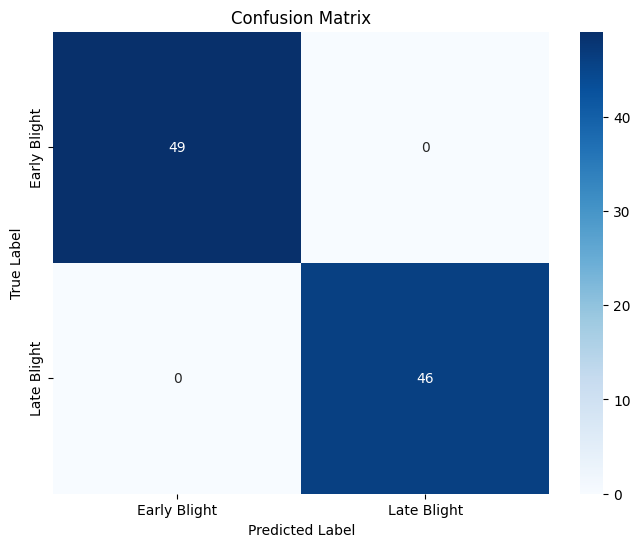

In [ ]:
# Evaluate the model on the test dataset
print("\nEvaluating model on test dataset...")
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions on the test dataset
predictions = model.predict(test_dataset)
y_pred = np.argmax(predictions, axis=1)
y_true = tf.concat([y for x, y in test_dataset], axis=0)

# Generate classification report and confusion matrix
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from google.colab import files
files.download('potato_disease_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import os

st.set_page_config(
    page_title="Potato Disease Classifier",
    page_icon="🥔",
    layout="centered"
)

st.title("🥔 Potato Disease Classification")
st.write("Upload an image of a potato leaf to detect Early Blight or Late Blight")

@st.cache_resource
def load_model():
    return tf.keras.models.load_model('potato_disease_model.keras')

def predict(image, model, class_names):
    img = image.resize((224, 224))
    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    predictions = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(predictions[0])
    confidence = np.max(predictions[0])

    return class_names[predicted_class], confidence

class_names = ['Early Blight', 'Late Blight']

try:
    model = load_model()
    st.success("Model loaded successfully")
except:
    st.error("Model not found. Please ensure model file exists.")

uploaded_file = st.file_uploader(
    "Choose an image...",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:
    image = Image.open(uploaded_file)
    st.image(image, caption="Uploaded Image", width=300)

    if st.button("Predict Disease"):
        with st.spinner("Analyzing..."):
            disease, confidence = predict(image, model, class_names)

        st.write("### Results")
        st.write(f"**Disease:** {disease}")
        st.write(f"**Confidence:** {confidence:.2%}")

        if disease == 'Early Blight':
            st.warning("⚠️ Early Blight detected. Consider using fungicides.")
        else:
            st.warning("⚠️ Late Blight detected. Consider immediate action.")

Writing app.py


In [ ]:
from google.colab import files
files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%%writefile requirements.txt
streamlit
tensorflow
numpy
pillow

Writing requirements.txt


In [ ]:
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>